# Code to analyze glacier elevation change (dH) rasters for Nevados de Chillán 
### performing geostpatial statistical analysis 

## Step 1: Compute mean slope, aspect, and elevation of each glacier, analyze whether elevation change is correlated with geospatial variable
### Question: is there a statistical relationship between glacier geography (mean elevation, aspect, slope) and mean glacier elevation loss?

In [27]:
import pandas as pd
import os
import glob
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# --------- USER SETTINGS ---------
csv_folder = "/Users/milliespencer/Glacier-DEM-coregistration-and-MB"
file_pattern = os.path.join(csv_folder, "*_summary.csv")
output_folder = os.path.join(csv_folder, "correlation_analysis")
os.makedirs(output_folder, exist_ok=True)

# --------- HELPER FUNCTIONS ---------

def calculate_and_plot_correlations(df, raster_label, output_folder):
    """
    For a given dataframe, compute and plot correlations between dH and terrain attributes.
    """
    results = []
    for var in ['elevation_mean', 'slope_mean', 'aspect_mean']:
        try:
            r, p = pearsonr(df['dH_mean'], df[var])
            results.append({
                "Raster": raster_label,
                "Variable": var,
                "Pearson_r": r,
                "p_value": p
            })

            sns.regplot(data=df, x=var, y='dH_mean', scatter_kws={'alpha': 0.5})
            plt.title(f"{raster_label}: dH_mean vs {var}\nPearson r = {r:.2f}, p = {p:.3f}")
            plt.xlabel(var)
            plt.ylabel("Mean dH (m)")
            plt.tight_layout()
            plot_path = os.path.join(output_folder, f"{raster_label}_{var}_correlation.png")
            plt.savefig(plot_path)
            plt.close()
            print(f"📈 Saved plot: {plot_path}")

        except Exception as e:
            print(f"⚠️ Could not calculate correlation for {raster_label} vs {var}: {e}")
    return results

def extract_years_from_label(label):
    """
    Extract raster year and glacier year from a filename label.
    Expects parts like '..._2019_glaciers2019_...' or '..._2000_glaciers2000_...'
    """
    parts = label.split('_')
    raster_year = None
    glacier_year = None
    
    for p in parts:
        if p in ['2000', '2019']:
            raster_year = p
        elif p.startswith('glaciers'):
            year_part = p.replace('glaciers', '')
            if year_part in ['2000', '2019']:
                glacier_year = year_part

    return raster_year, glacier_year

# --------- MAIN ANALYSIS ---------

def main():
    all_results = []

    for filepath in glob.glob(file_pattern):
        filename = os.path.basename(filepath)
        raster_label = filename.replace("_summary.csv", "")

        raster_year, glacier_year = extract_years_from_label(raster_label)

        if raster_year is None or glacier_year is None:
            print(f"⚠️ Cannot determine years for {filename}, skipping.")
            continue

        if raster_year != glacier_year:
            print(f"⚠️ Skipping {filename} because raster year ({raster_year}) != glacier year ({glacier_year})")
            continue

        print(f"\n🔍 Analyzing: {raster_label}")

        try:
            df = pd.read_csv(filepath)
            df = df.dropna(subset=['dH_mean', 'slope_mean', 'aspect_mean', 'elevation_mean'])
            if df.empty:
                print(f"⚠️ Skipped {raster_label} (no valid data)")
                continue

            res = calculate_and_plot_correlations(df, raster_label, output_folder)
            all_results.extend(res)

        except Exception as e:
            print(f"⚠️ Error reading {filename}: {e}")
            continue

    results_df = pd.DataFrame(all_results)
    results_csv = os.path.join(output_folder, "correlation_summary.csv")
    results_df.to_csv(results_csv, index=False)
    print(f"\n✅ Saved correlation summary table to: {results_csv}")


if __name__ == "__main__":
    main()



✅ Saved correlation summary table to: /Users/milliespencer/Glacier-DEM-coregistration-and-MB/correlation_analysis/correlation_summary.csv


### Result: no statistically significant relationship between mean glacier elevation, aspect, or slope and mean glacier elevation loss. Our data does not suggest a relationship between a glacier's elevation loss and its geographic attributes. 

## Step 2: Let's look at the pixel level, not just glaciers or whole subcomplexes
## Here we: analyze dH per pixel, and calculate mean, median, and standard deviation of dH 


📂 Year: 2000
🔵 Raster: SRTMminusIGM_2000


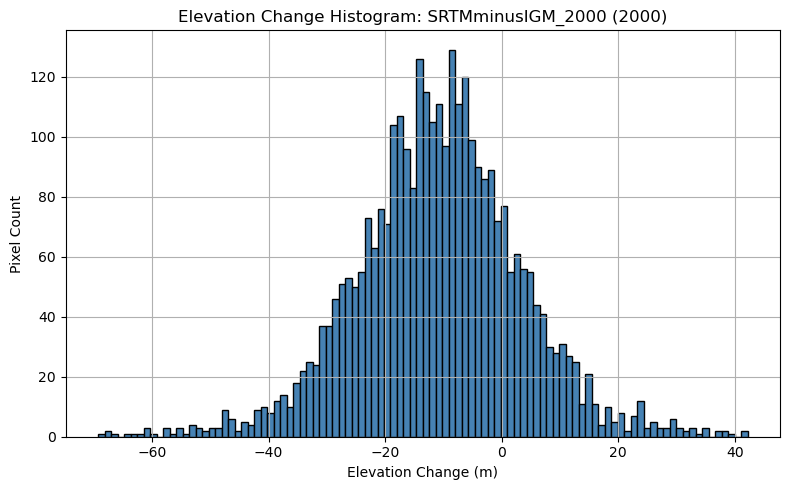

✅ 3224 valid pixels analyzed.
📊 Mean: -10.90 m | Median: -10.89 m | Std: 14.29 m

📂 Year: 2000
🔵 Raster: CBminusSRTM_2000


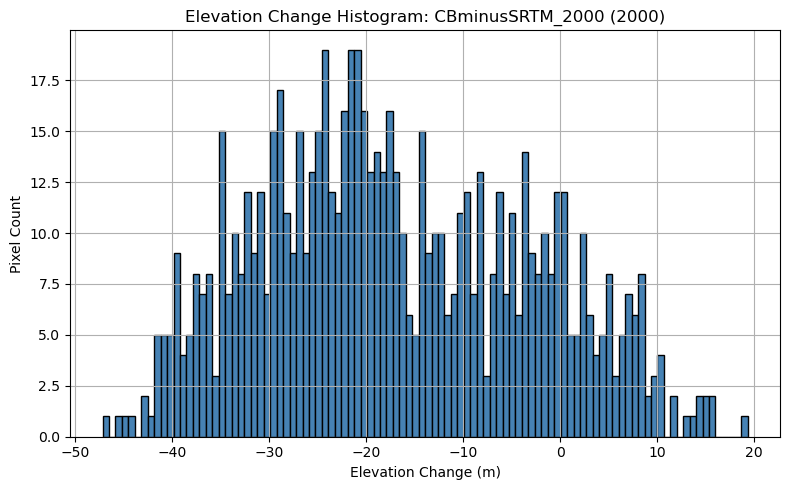

✅ 764 valid pixels analyzed.
📊 Mean: -17.02 m | Median: -18.87 m | Std: 13.82 m

📂 Year: 2000
🔵 Raster: LTminusSRTM_2000


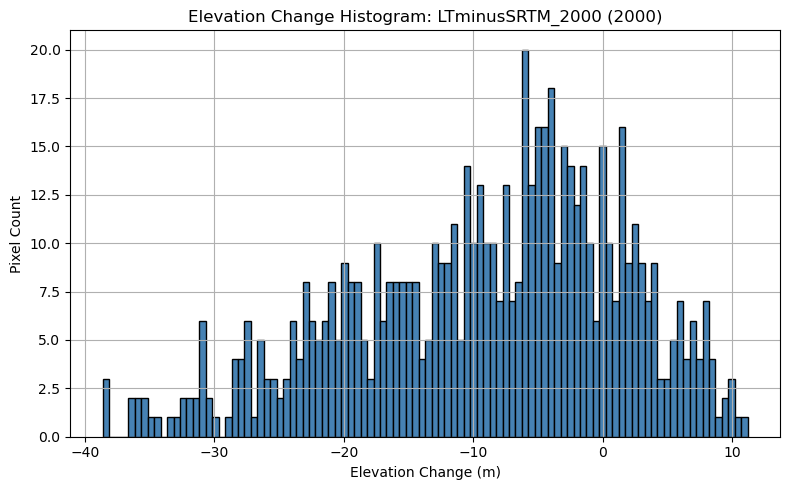

✅ 649 valid pixels analyzed.
📊 Mean: -9.08 m | Median: -7.43 m | Std: 10.53 m

📂 Year: 2000
🔵 Raster: CBminusIGM_2000


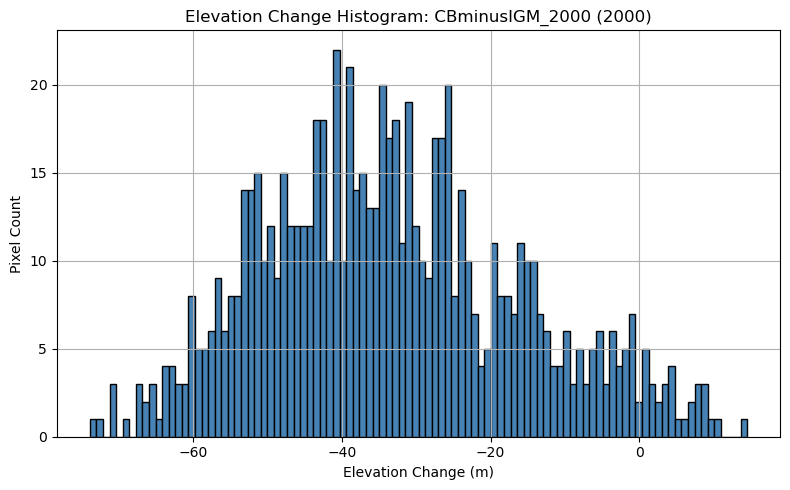

✅ 764 valid pixels analyzed.
📊 Mean: -33.43 m | Median: -34.45 m | Std: 17.24 m

📂 Year: 2000
🔵 Raster: LTminusIGM_2000


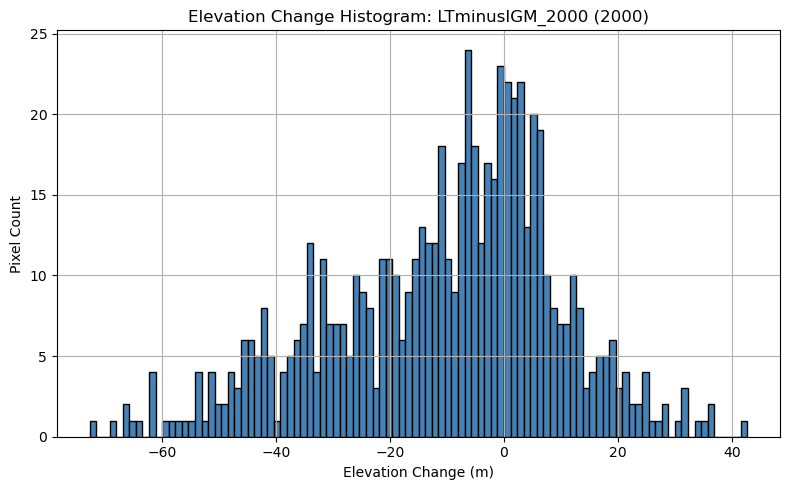

✅ 649 valid pixels analyzed.
📊 Mean: -10.61 m | Median: -6.75 m | Std: 20.11 m

📂 Year: 2019
🔵 Raster: SRTMminusIGM_2019


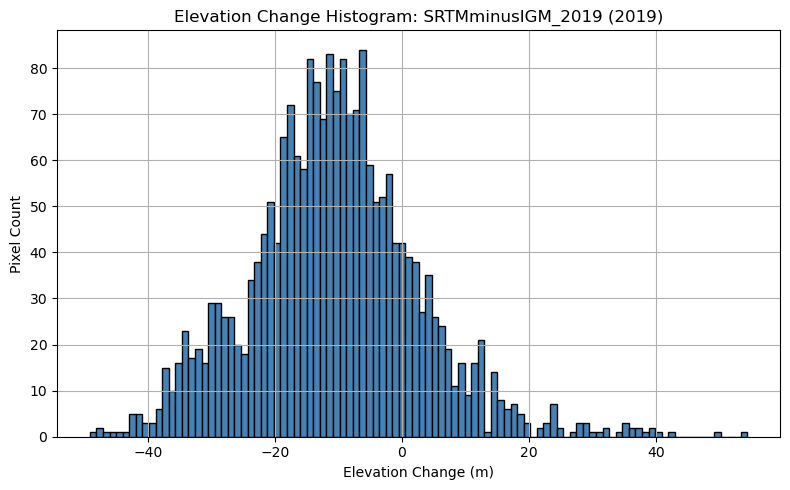

✅ 2119 valid pixels analyzed.
📊 Mean: -10.65 m | Median: -11.01 m | Std: 13.34 m

📂 Year: 2019
🔵 Raster: CBminusSRTM_2019


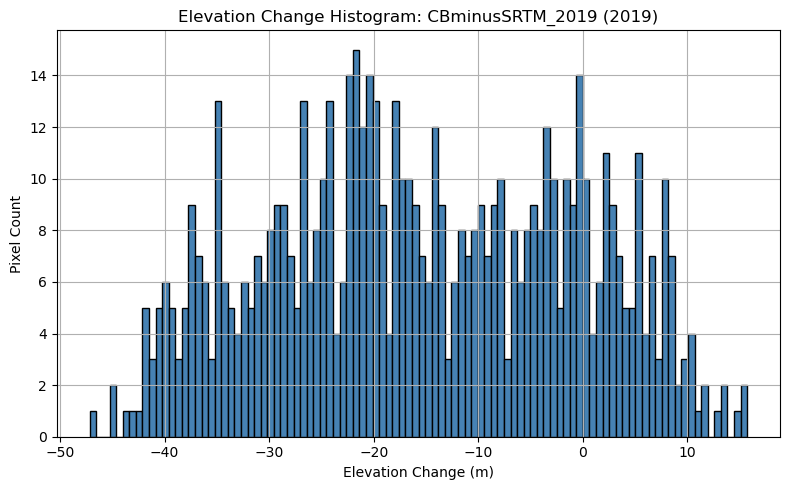

✅ 656 valid pixels analyzed.
📊 Mean: -15.29 m | Median: -16.28 m | Std: 14.44 m

📂 Year: 2019
🔵 Raster: LTminusSRTM_2019


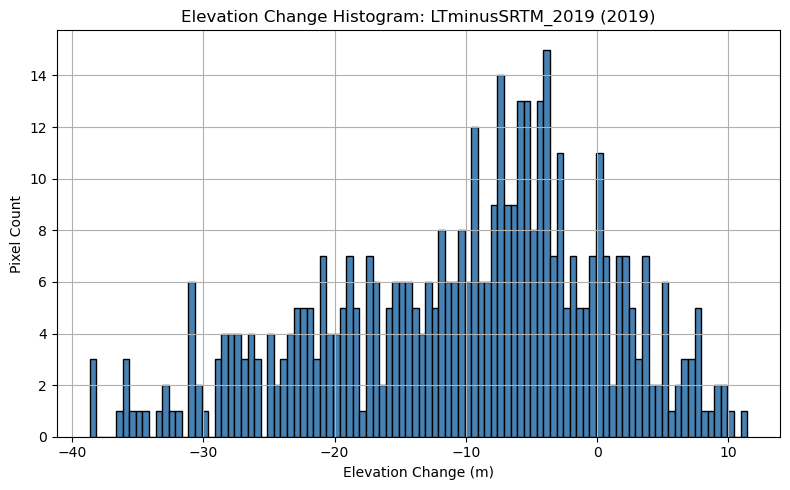

✅ 460 valid pixels analyzed.
📊 Mean: -10.16 m | Median: -8.01 m | Std: 10.65 m

📂 Year: 2019
🔵 Raster: CBminusIGM_2019


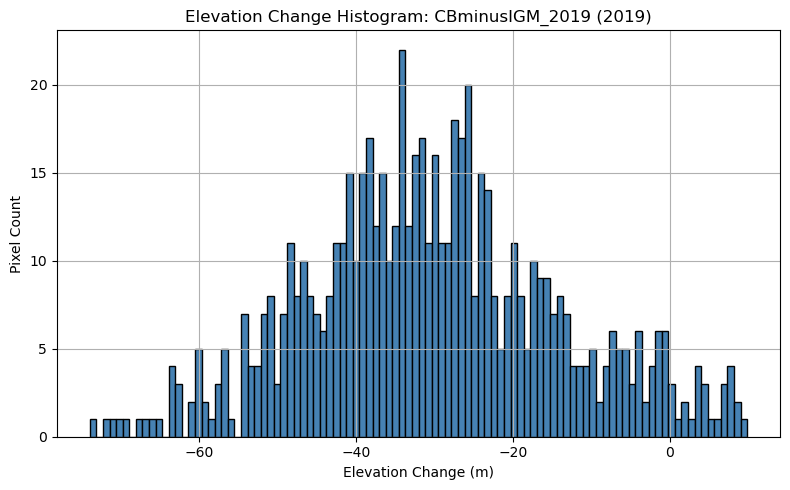

✅ 656 valid pixels analyzed.
📊 Mean: -30.25 m | Median: -31.20 m | Std: 16.08 m

📂 Year: 2019
🔵 Raster: LTminusIGM_2019


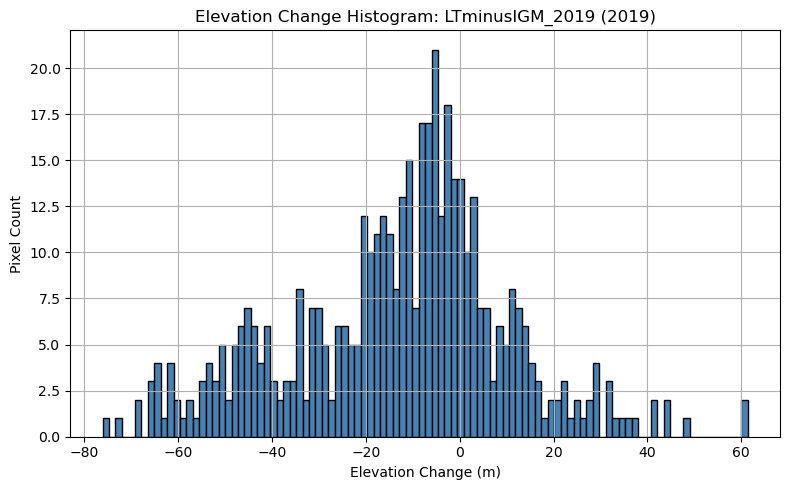

✅ 460 valid pixels analyzed.
📊 Mean: -13.06 m | Median: -10.05 m | Std: 23.37 m


In [28]:
import os
import geopandas as gpd
import rasterio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from rasterio.mask import mask
from shapely.geometry import mapping

# ----------------------------
# Paths to glacier outlines
# ----------------------------
glacier_outlines = {
    "2000": "/Users/milliespencer/Glacier-DEM-coregistration-and-MB/example_data_Nevados/Nevados_glacier_shapefiles/Nevados_shapefile_DGA2000/Nevados_polygons_DGA2000.shp",
    "2019": "/Users/milliespencer/Glacier-DEM-coregistration-and-MB/example_data_Nevados/Nevados_glacier_shapefiles/Nevados_shapefile_DGA2019/Nevados_polygons_DGA2019.shp"
}

# ----------------------------
# Paths to elevation difference rasters
# ----------------------------
raster_paths = {
    "SRTMminusIGM_2000": "/Users/milliespencer/Desktop/dems_20250721_updated/output_data_baseIGM_poly2000_updated/SRTM_projected_raste_clp_diff.tif",
    "CBminusSRTM_2000": "/Users/milliespencer/Desktop/dems_20250721_updated/output_data_baseSRTM_poly2000/CerroBlanco_DEMproje_clp_diff.tif",
    "LTminusSRTM_2000": "/Users/milliespencer/Desktop/dems_20250721_updated/output_data_baseSRTM_poly2000/LasTermas_DEMproject_clp_diff.tif",
    "CBminusIGM_2000": "/Users/milliespencer/Desktop/dems_20250721_updated/output_data_baseIGM_poly2000_updated/CerroBlanco_DEMproje_clp_diff.tif",
    "LTminusIGM_2000": "/Users/milliespencer/Desktop/dems_20250721_updated/output_data_baseIGM_poly2000_updated/LasTermas_DEMproject_clp_diff.tif",
    "SRTMminusIGM_2019": "/Users/milliespencer/Desktop/dems_20250721_updated/output_data_baseIGM_poly2019_updated/SRTM_projected_raste_clp_diff.tif",
    "CBminusSRTM_2019": "/Users/milliespencer/Desktop/dems_20250721_updated/output_data_baseSRTM_poly2019/CerroBlanco_DEMproje_clp_diff.tif",
    "LTminusSRTM_2019": "/Users/milliespencer/Desktop/dems_20250721_updated/output_data_baseSRTM_poly2019/LasTermas_DEMproject_clp_diff.tif",
    "CBminusIGM_2019": "/Users/milliespencer/Desktop/dems_20250721_updated/output_data_baseIGM_poly2019_updated/CerroBlanco_DEMproje_clp_diff.tif",
    "LTminusIGM_2019": "/Users/milliespencer/Desktop/dems_20250721_updated/output_data_baseIGM_poly2019_updated/LasTermas_DEMproject_clp_diff.tif"
}

# ----------------------------
# Function to extract valid elevation change pixels
# ----------------------------
def extract_valid_pixels(raster_path, glacier_polygon):
    if glacier_polygon is None:
        return np.array([])  # Skip None geometries

    try:
        with rasterio.open(raster_path) as src:
            out_image, _ = mask(src, [mapping(glacier_polygon)], crop=True)
            out_image = out_image[0]

            # Replace extreme values with NaN
            out_image = np.where((out_image >= 1e38) | (out_image <= -9999), np.nan, out_image)
            return out_image.flatten()
    except ValueError as e:
        if "Input shapes do not overlap raster" in str(e):
            return np.array([])  # No overlap: return empty
        else:
            raise e
    except Exception as e:
        print(f"❌ Unexpected error during masking: {e}")
        return np.array([])

# ----------------------------
# Process rasters
# ----------------------------
output_dir = "/Users/milliespencer/Desktop/70_Years_MB_Nevados/Nevados_dH_Stats/pixel_stats"
os.makedirs(output_dir, exist_ok=True)

for raster_name, raster_path in raster_paths.items():
    # Automatically select the correct glacier shapefile based on year
    if "_2000" in raster_name:
        year = "2000"
    elif "_2019" in raster_name:
        year = "2019"
    else:
        print(f"❌ Could not determine year from raster name: {raster_name}")
        continue

    print(f"\n📂 Year: {year}\n🔵 Raster: {raster_name}")

    gdf = gpd.read_file(glacier_outlines[year])
    all_pixels = []

    for _, row in gdf.iterrows():
        if row.geometry is None or row.geometry.is_empty:
            continue  # Skip missing or empty geometries

        pixels = extract_valid_pixels(raster_path, row.geometry)
        valid_pixels = pixels[~np.isnan(pixels)]
        all_pixels.extend(valid_pixels)

    all_pixels = np.array(all_pixels)

    if all_pixels.size == 0:
        print("⚠️ No valid pixels found in raster-glacier intersection. Skipping.")
        continue

    # Save pixels to CSV
    output_csv = os.path.join(output_dir, f"{raster_name}_{year}_pixels.csv")
    pd.DataFrame(all_pixels, columns=["dh"]).to_csv(output_csv, index=False)

    # Plot histogram of elevation changes
    plt.figure(figsize=(8, 5))
    plt.hist(all_pixels, bins=100, color='steelblue', edgecolor='black')
    plt.title(f"Elevation Change Histogram: {raster_name} ({year})")
    plt.xlabel("Elevation Change (m)")
    plt.ylabel("Pixel Count")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Print summary statistics
    print(f"✅ {len(all_pixels)} valid pixels analyzed.")
    print(f"📊 Mean: {np.mean(all_pixels):.2f} m | Median: {np.median(all_pixels):.2f} m | Std: {np.std(all_pixels):.2f} m")


# Step 3: Geospatial analysis
## is glacier elevation loss for a 30x30 pixel related to its geographic attributes? 
### E.g. do steeper pixels have a higher or lower elevation loss than flatter pixels? What about pixels at higher/lower elevations? North vs East aspect? 

Here we: 
- Load each raster’s elevation change pixels (dH) from the CSVs you saved in Step 2
- Extract the pixels’ elevation, slope, and aspect from the SRTM DEM raster (for consistency just using this raster)
- Combine dH and geographic variables per pixel
- Perform correlation analysis between dH and elevation, slope, and aspect
- Plot the relationships with regression lines and reports correlation coefficients and p-values

Loading DEM and calculating slope/aspect...
Done with DEM preprocessing.

Processing SRTMminusIGM_2000_2000_pixels.csv for year 2000
dH pixels: 3224, elev: 3224, slope: 3224, aspect: 3224
dH vs elevation | r = 0.443, r² = 0.196, p = 2.81e-155


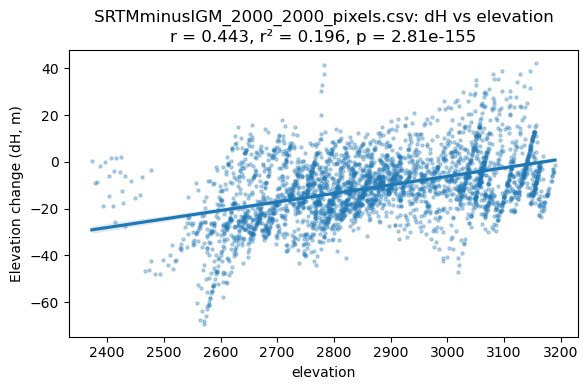

dH vs slope | r = -0.005, r² = 0.000, p = 0.758


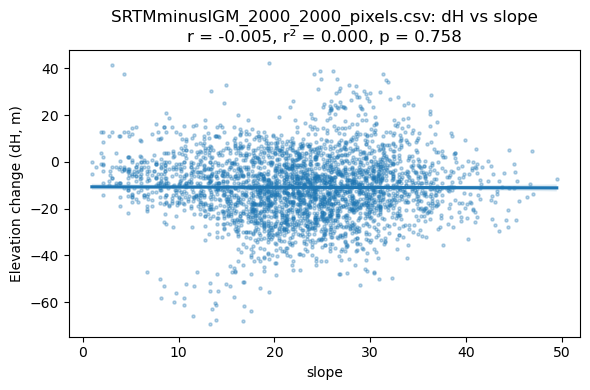

dH vs aspect | r = -0.022, r² = 0.000, p = 0.206


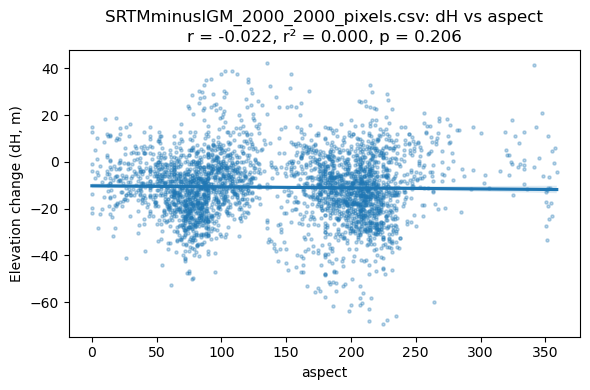

Skipping SRTMminusIGM_2019_2000_pixels.csv because years do not match or are ambiguous: ['2019', '2000']

Processing SRTMminusIGM_2019_2019_pixels.csv for year 2019
dH pixels: 2119, elev: 2119, slope: 2119, aspect: 2119
dH vs elevation | r = 0.264, r² = 0.069, p = 5.35e-35


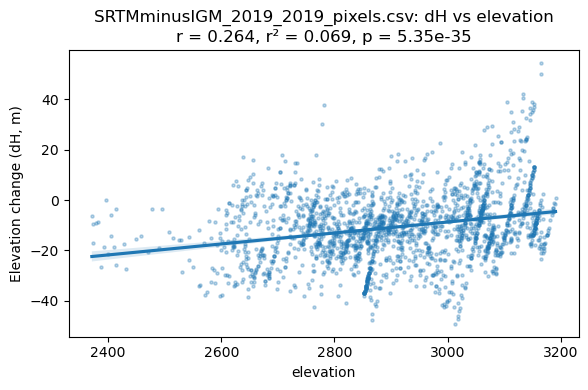

dH vs slope | r = 0.065, r² = 0.004, p = 0.00262


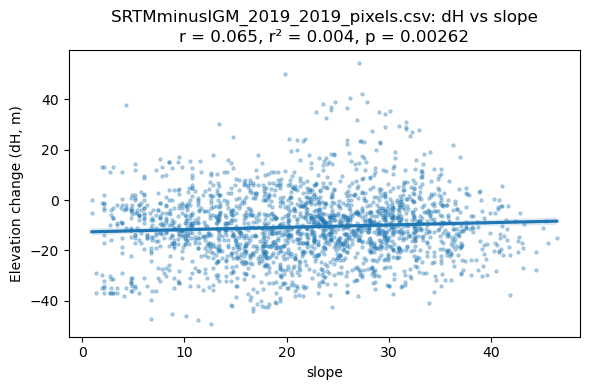

dH vs aspect | r = -0.126, r² = 0.016, p = 6.15e-09


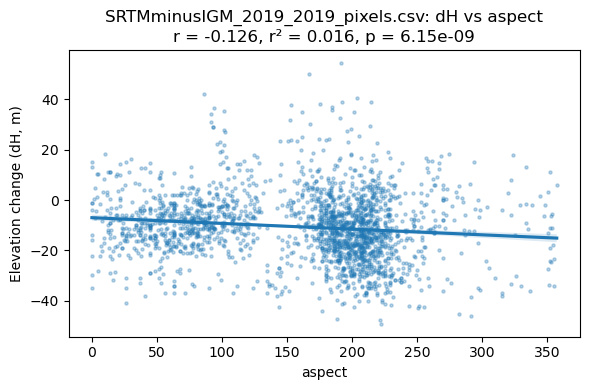


Processing LTminusIGM_2000_2000_pixels.csv for year 2000
dH pixels: 649, elev: 3224, slope: 3224, aspect: 3224
dH vs elevation | r = 0.296, r² = 0.088, p = 1.42e-14


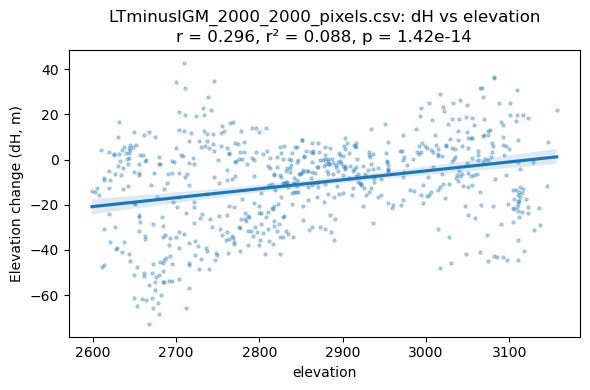

dH vs slope | r = 0.115, r² = 0.013, p = 0.0033


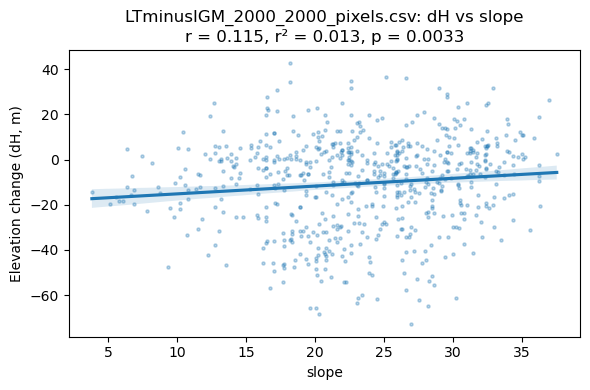

dH vs aspect | r = 0.018, r² = 0.000, p = 0.645


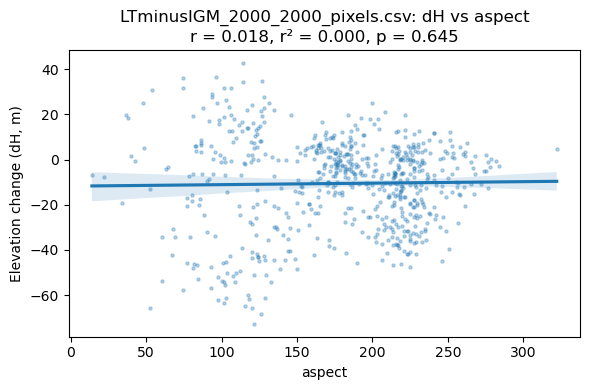


Processing LTminusIGM_2019_2019_pixels.csv for year 2019
dH pixels: 460, elev: 2119, slope: 2119, aspect: 2119
dH vs elevation | r = 0.136, r² = 0.018, p = 0.00352


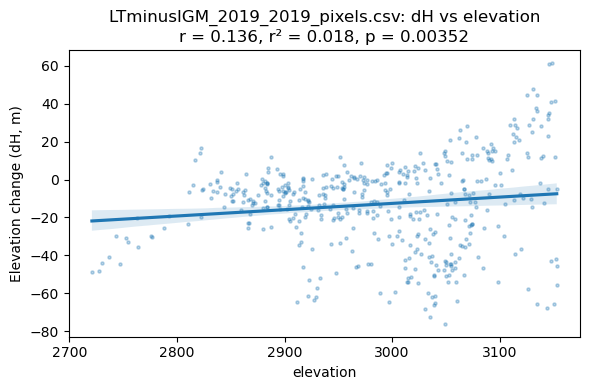

dH vs slope | r = 0.190, r² = 0.036, p = 4.17e-05


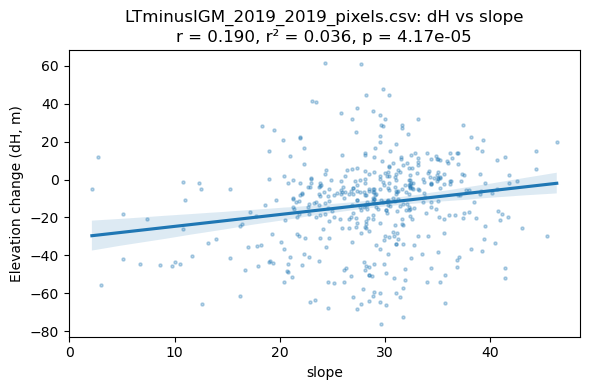

dH vs aspect | r = -0.047, r² = 0.002, p = 0.316


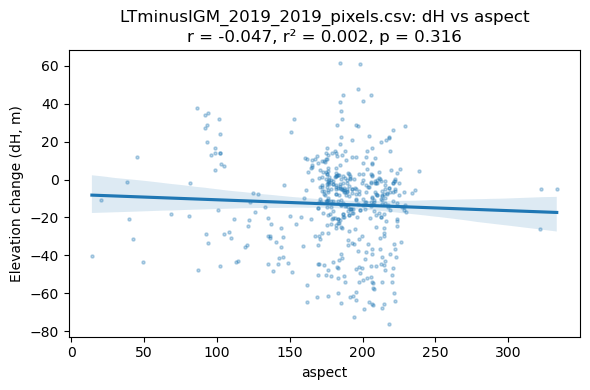


Processing CBminusSRTM_2019_2019_pixels.csv for year 2019
dH pixels: 656, elev: 2119, slope: 2119, aspect: 2119
dH vs elevation | r = 0.388, r² = 0.151, p = 5.19e-25


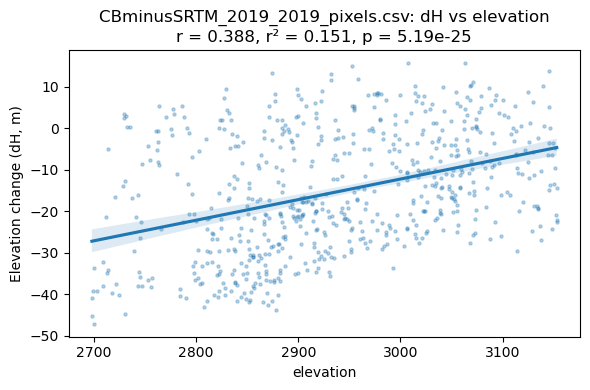

dH vs slope | r = 0.202, r² = 0.041, p = 1.71e-07


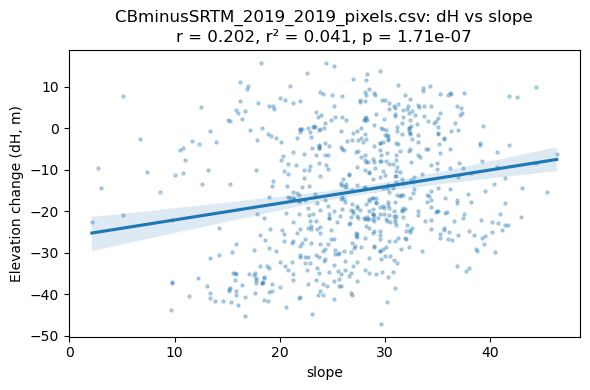

dH vs aspect | r = -0.283, r² = 0.080, p = 1.46e-13


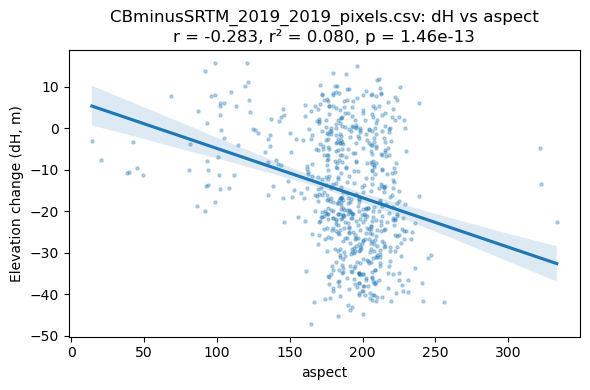


Processing CBminusSRTM_2000_2000_pixels.csv for year 2000
dH pixels: 764, elev: 3224, slope: 3224, aspect: 3224
dH vs elevation | r = 0.376, r² = 0.141, p = 4.96e-27


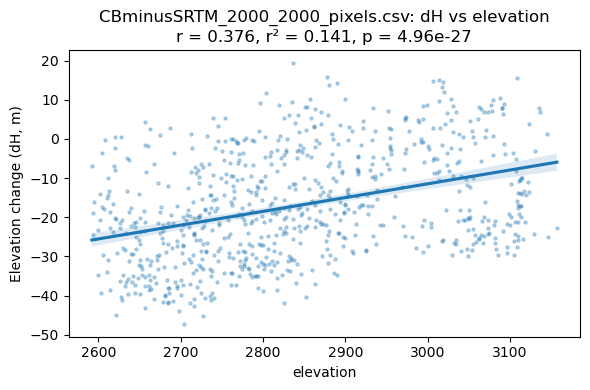

dH vs slope | r = 0.238, r² = 0.057, p = 2.51e-11


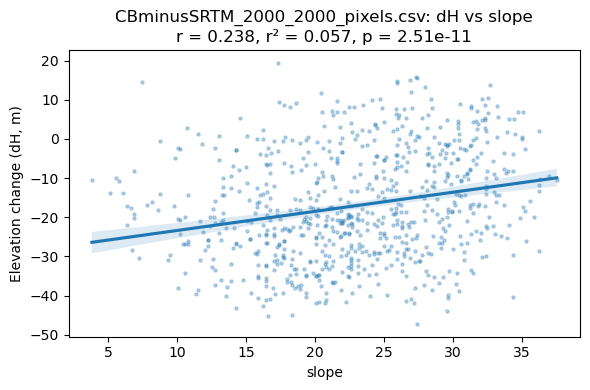

dH vs aspect | r = 0.037, r² = 0.001, p = 0.313


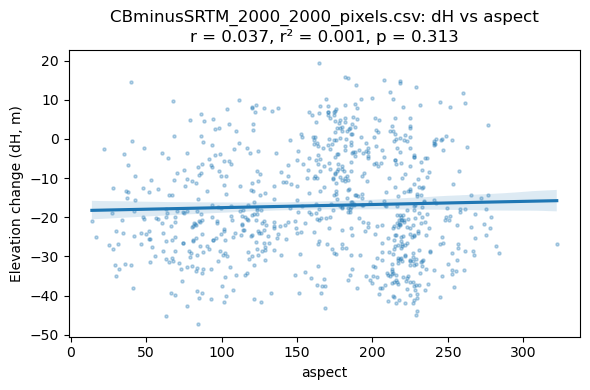


Processing CBminusIGM_2019_2019_pixels.csv for year 2019
dH pixels: 656, elev: 2119, slope: 2119, aspect: 2119
dH vs elevation | r = 0.471, r² = 0.222, p = 1.3e-37


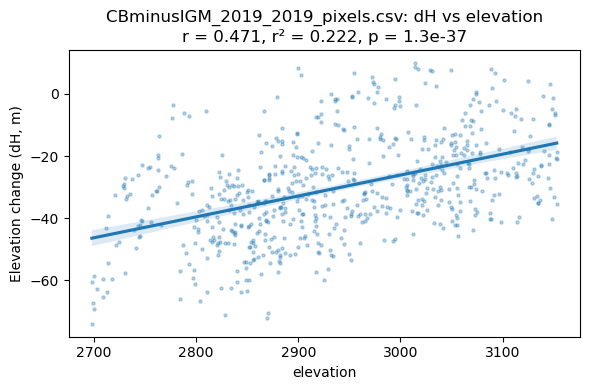

dH vs slope | r = 0.216, r² = 0.047, p = 2.18e-08


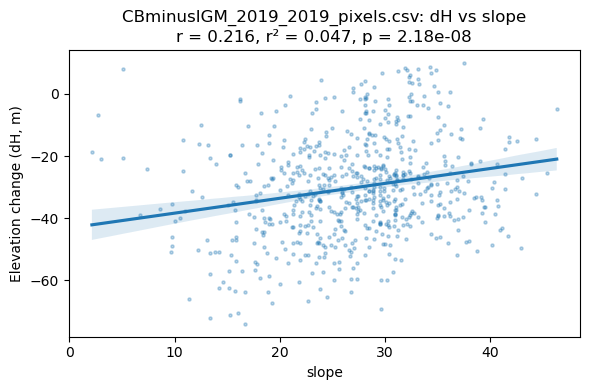

dH vs aspect | r = -0.224, r² = 0.050, p = 6.58e-09


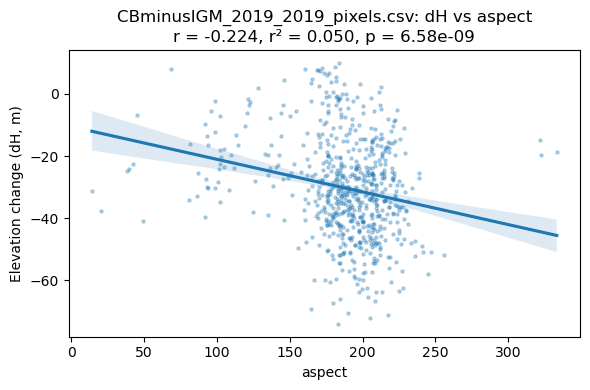


Processing LTminusSRTM_2000_2000_pixels.csv for year 2000
dH pixels: 649, elev: 3224, slope: 3224, aspect: 3224
dH vs elevation | r = 0.053, r² = 0.003, p = 0.175


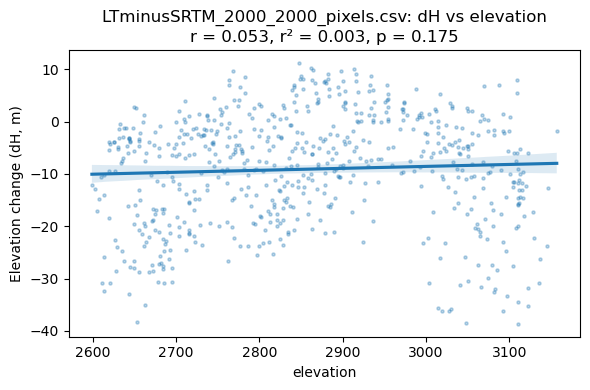

dH vs slope | r = 0.172, r² = 0.030, p = 1.01e-05


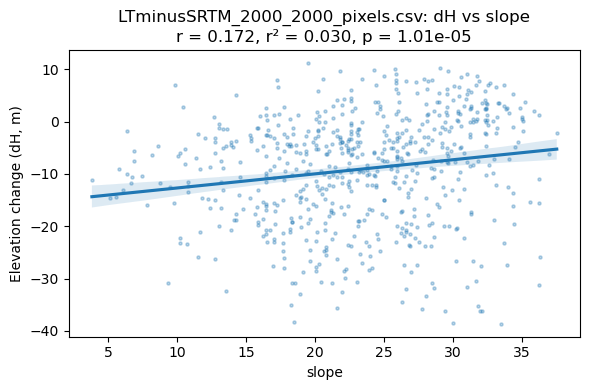

dH vs aspect | r = 0.129, r² = 0.017, p = 0.000958


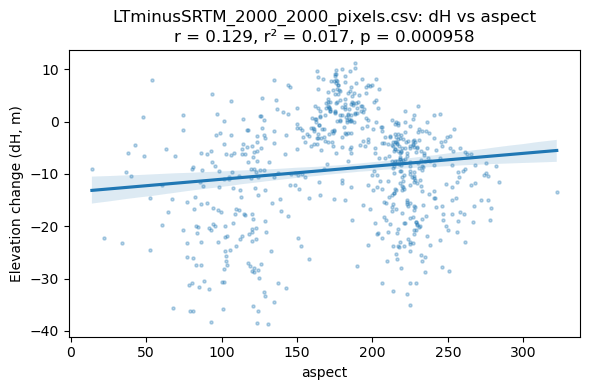


Processing LTminusSRTM_2019_2019_pixels.csv for year 2019
dH pixels: 460, elev: 2119, slope: 2119, aspect: 2119
dH vs elevation | r = -0.238, r² = 0.057, p = 2.39e-07


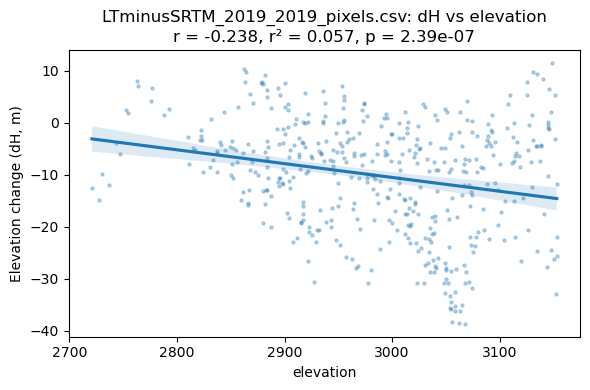

dH vs slope | r = 0.282, r² = 0.080, p = 6.97e-10


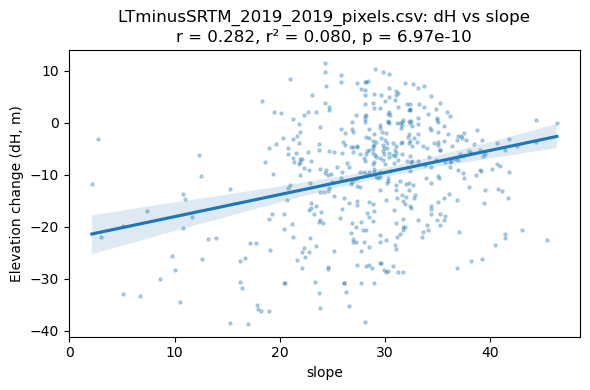

dH vs aspect | r = 0.066, r² = 0.004, p = 0.159


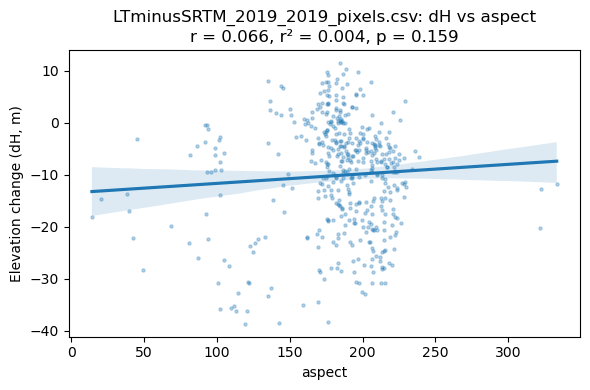


Processing CBminusIGM_2000_2000_pixels.csv for year 2000
dH pixels: 764, elev: 3224, slope: 3224, aspect: 3224
dH vs elevation | r = 0.535, r² = 0.286, p = 9e-58


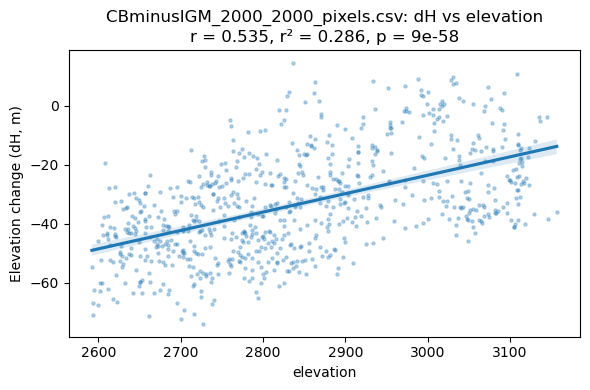

dH vs slope | r = 0.265, r² = 0.070, p = 1.02e-13


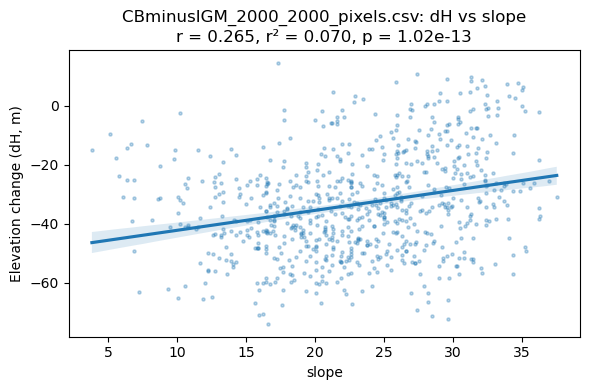

dH vs aspect | r = 0.102, r² = 0.010, p = 0.00464


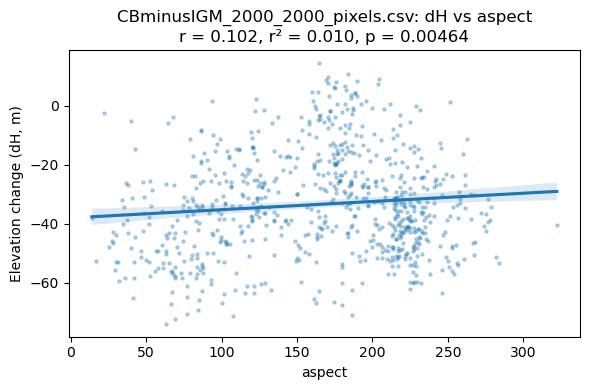

In [29]:
import os
import pandas as pd
import numpy as np
import rasterio
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
import geopandas as gpd
from rasterio.mask import mask

# Folder where Step 1 saved dH CSV files
dH_csv_folder = "/Users/milliespencer/Desktop/70_Years_MB_Nevados/Nevados_dH_Stats/pixel_stats"

# Path to the true elevation DEM raster (SRTM)
dem_path = "/Users/milliespencer/Desktop/dems_20250721_updated/SRTM_projected_raster.tif"

# Paths to glacier shapefiles by year
glacier_shapefiles = {
    "2000": "/Users/milliespencer/Glacier-DEM-coregistration-and-MB/example_data_Nevados/Nevados_glacier_shapefiles/Nevados_shapefile_DGA2000/Nevados_polygons_DGA2000.shp",
    "2019": "/Users/milliespencer/Glacier-DEM-coregistration-and-MB/example_data_Nevados/Nevados_glacier_shapefiles/Nevados_shapefile_DGA2019/Nevados_polygons_DGA2019.shp"
}

def calculate_slope_aspect(dem_array, dem_transform):
    xres = dem_transform[0]
    yres = -dem_transform[4]

    dy, dx = np.gradient(dem_array, yres, xres)
    slope_rad = np.arctan(np.sqrt(dx**2 + dy**2))
    slope_deg = np.degrees(slope_rad)

    aspect_rad = np.arctan2(-dx, dy)
    aspect_deg = np.degrees(aspect_rad)
    aspect_deg = np.where(aspect_deg < 0, 360 + aspect_deg, aspect_deg)

    return slope_deg, aspect_deg

print("Loading DEM and calculating slope/aspect...")
with rasterio.open(dem_path) as dem_src:
    dem_arr = dem_src.read(1)
    dem_arr = np.where((dem_arr >= 1e38) | (dem_arr <= -9999), np.nan, dem_arr)
    dem_transform = dem_src.transform
    slope_arr, aspect_arr = calculate_slope_aspect(dem_arr, dem_transform)
print("Done with DEM preprocessing.")

# Loop over each dH CSV file from Step 1
for filename in os.listdir(dH_csv_folder):
    if not filename.endswith(".csv"):
        continue

    parts = filename.split('_')
    years_in_name = [p for p in parts if p in ["2000", "2019"]]

    if len(years_in_name) != 2 or years_in_name[0] != years_in_name[1]:
        print(f"Skipping {filename} because years do not match or are ambiguous: {years_in_name}")
        continue

    year = years_in_name[0]
    print(f"\nProcessing {filename} for year {year}")

    # Load glacier polygons for this year
    gdf = gpd.read_file(glacier_shapefiles[year])

    # Load dH values
    dH_df = pd.read_csv(os.path.join(dH_csv_folder, filename))
    dH_values = dH_df['dh'].values

    all_dem_elev = []
    all_dem_slope = []
    all_dem_aspect = []

    with rasterio.open(dem_path) as dem_src:
        for _, row in gdf.iterrows():
            if row.geometry is None or row.geometry.is_empty:
                continue
            try:
                window_image, window_transform = mask(dem_src, [row.geometry], crop=True)
                window_elev = window_image[0]
                window_elev = np.where((window_elev >= 1e38) | (window_elev <= -9999), np.nan, window_elev)

                rows, cols = np.where(~np.isnan(window_elev))

                global_rows = rows + int((window_transform.f - dem_transform.f) / dem_transform.e)
                global_cols = cols + int((window_transform.c - dem_transform.c) / dem_transform.a)

                elev_vals = window_elev[rows, cols]
                slope_vals = slope_arr[global_rows, global_cols]
                aspect_vals = aspect_arr[global_rows, global_cols]

                all_dem_elev.extend(elev_vals)
                all_dem_slope.extend(slope_vals)
                all_dem_aspect.extend(aspect_vals)

            except Exception as e:
                print(f"Error processing polygon: {e}")
                continue

    all_dem_elev = np.array(all_dem_elev)
    all_dem_slope = np.array(all_dem_slope)
    all_dem_aspect = np.array(all_dem_aspect)

    print(f"dH pixels: {len(dH_values)}, elev: {len(all_dem_elev)}, slope: {len(all_dem_slope)}, aspect: {len(all_dem_aspect)}")
    min_len = min(len(dH_values), len(all_dem_elev), len(all_dem_slope), len(all_dem_aspect))

    if min_len == 0:
        print(f"No valid combined data for {filename}, skipping.")
        continue

    dH_values = dH_values[:min_len]
    all_dem_elev = all_dem_elev[:min_len]
    all_dem_slope = all_dem_slope[:min_len]
    all_dem_aspect = all_dem_aspect[:min_len]

    df = pd.DataFrame({
        'dH': dH_values,
        'elevation': all_dem_elev,
        'slope': all_dem_slope,
        'aspect': all_dem_aspect
    }).dropna()

    if df.empty:
        print(f"No valid data after dropping NaNs for {filename}, skipping.")
        continue

    for var in ['elevation', 'slope', 'aspect']:
        r, p = pearsonr(df['dH'], df[var])
        r2 = r ** 2
        print(f"dH vs {var} | r = {r:.3f}, r² = {r2:.3f}, p = {p:.3g}")

        plt.figure(figsize=(6, 4))
        sns.regplot(x=var, y='dH', data=df, scatter_kws={'alpha': 0.3, 's': 5})
        plt.title(f"{filename}: dH vs {var}\nr = {r:.3f}, r² = {r2:.3f}, p = {p:.3g}")
        plt.xlabel(var)
        plt.ylabel("Elevation change (dH, m)")
        plt.tight_layout()
        plt.show()


Across the board small r2 values. Weak relationship between dH and geographic variables. Some predictive power, but low.


## SPATIAL AUTOCORRELATION ANALYSIS: are nearer pixels similar in dH value? 


Analyzing SRTMminusIGM_2000
Data shape: 254 rows x 233 cols
Global Moran’s I: 0.7768, p-value: 0.0010


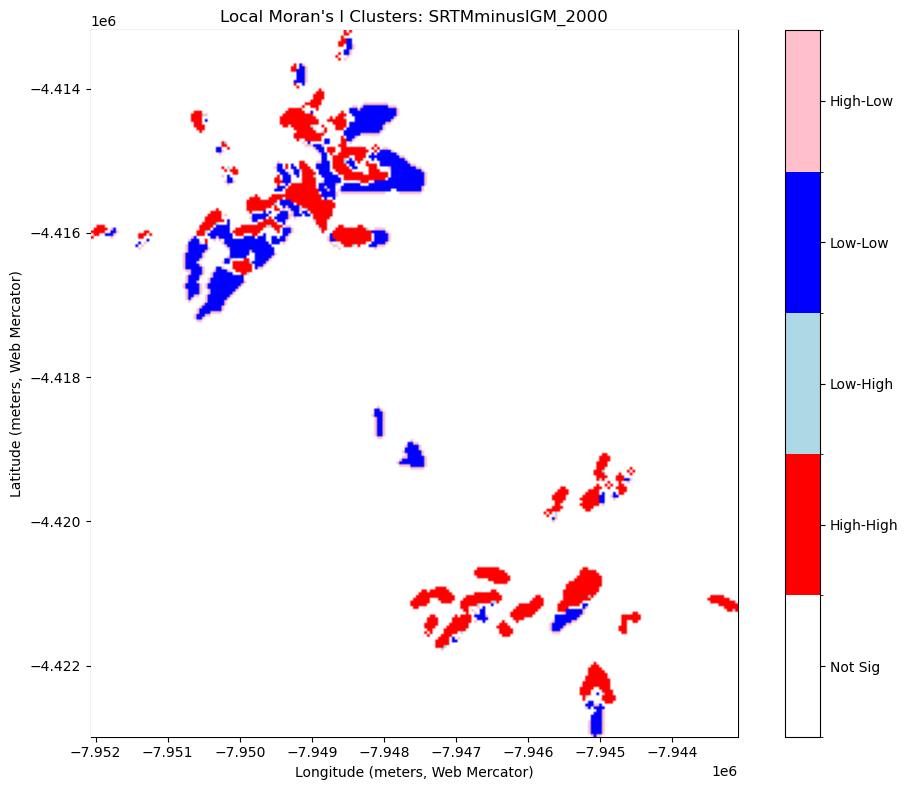


Analyzing CBminusSRTM_2000
Data shape: 46 rows x 40 cols
Global Moran’s I: 0.8023, p-value: 0.0010


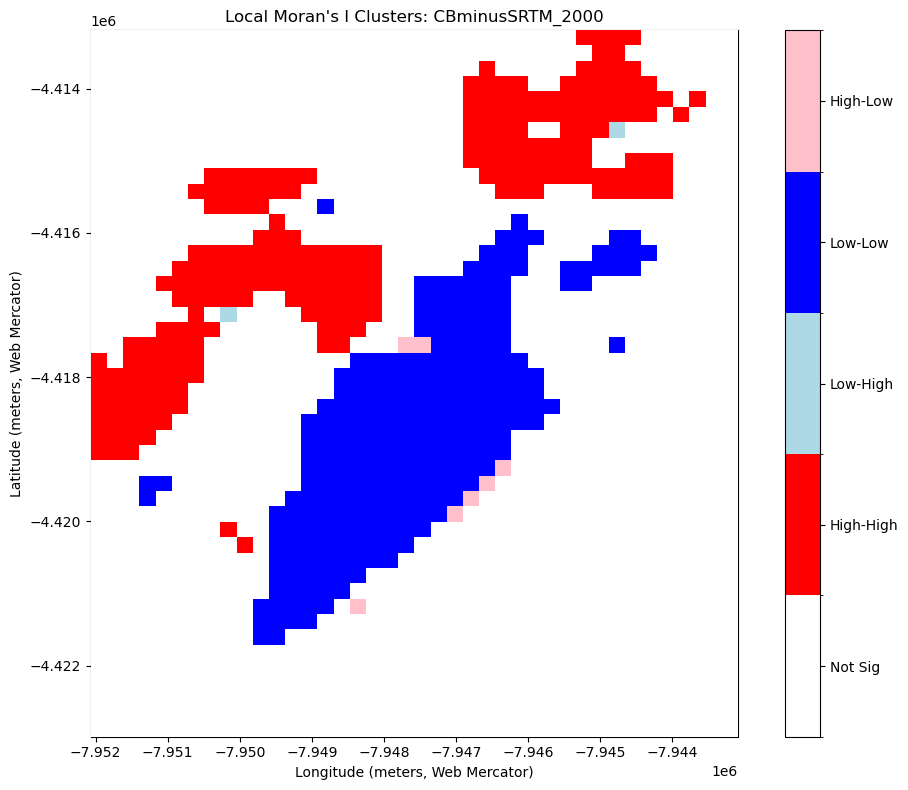


Analyzing LTminusSRTM_2000
Data shape: 60 rows x 81 cols
Global Moran’s I: 0.8234, p-value: 0.0010


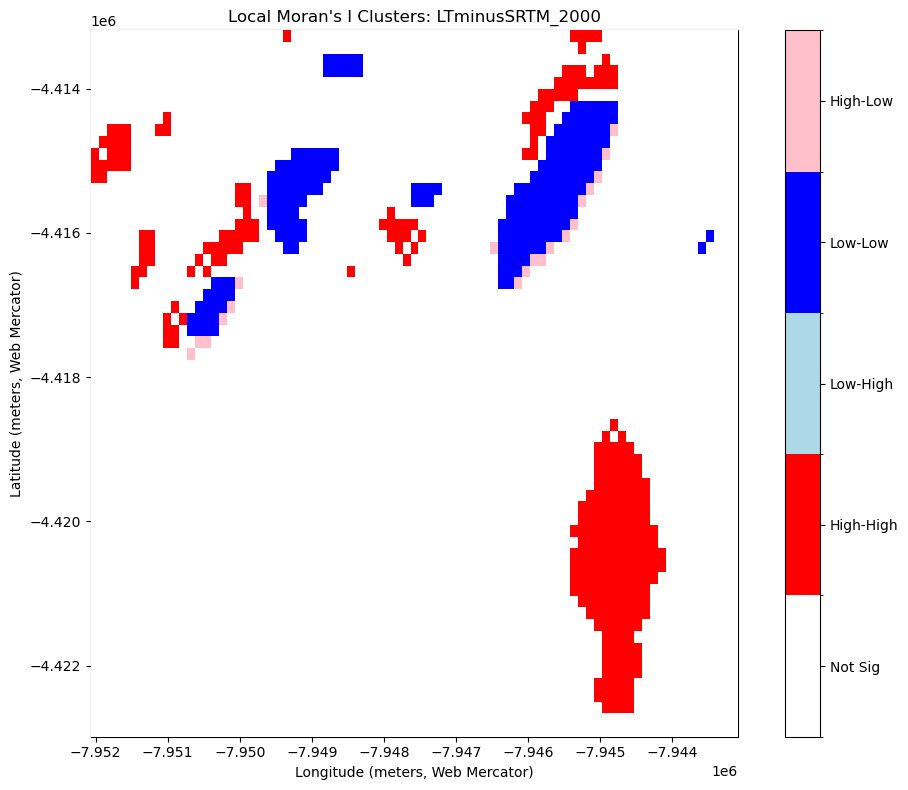


Analyzing CBminusIGM_2000
Data shape: 46 rows x 40 cols
Global Moran’s I: 0.8065, p-value: 0.0010


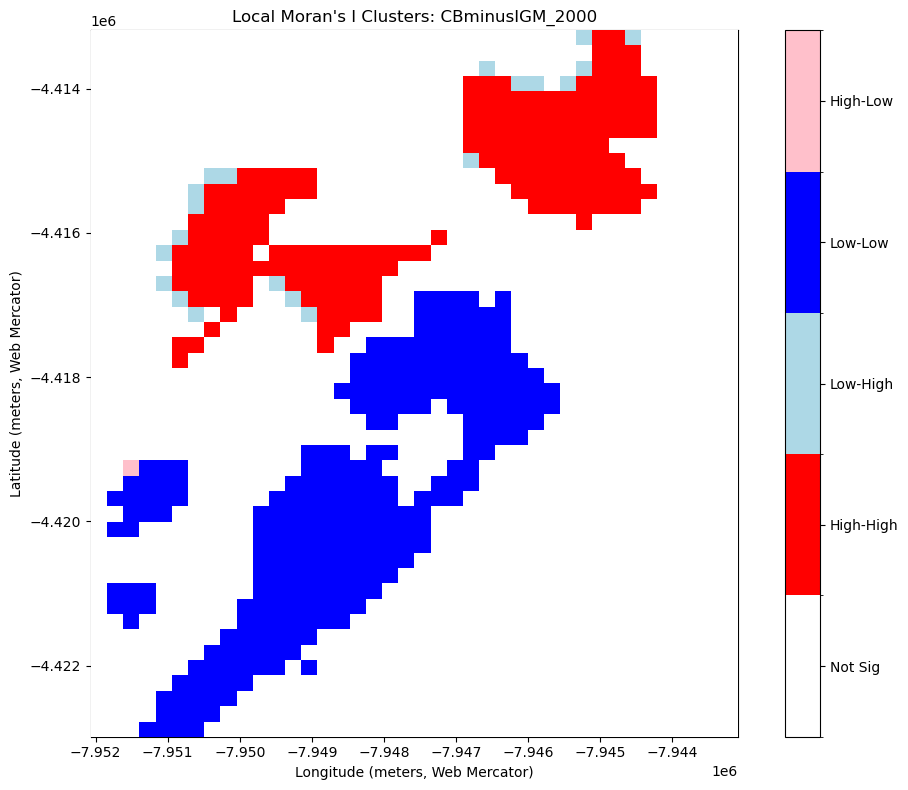


Analyzing LTminusIGM_2000
Data shape: 60 rows x 81 cols
Global Moran’s I: 0.7865, p-value: 0.0010


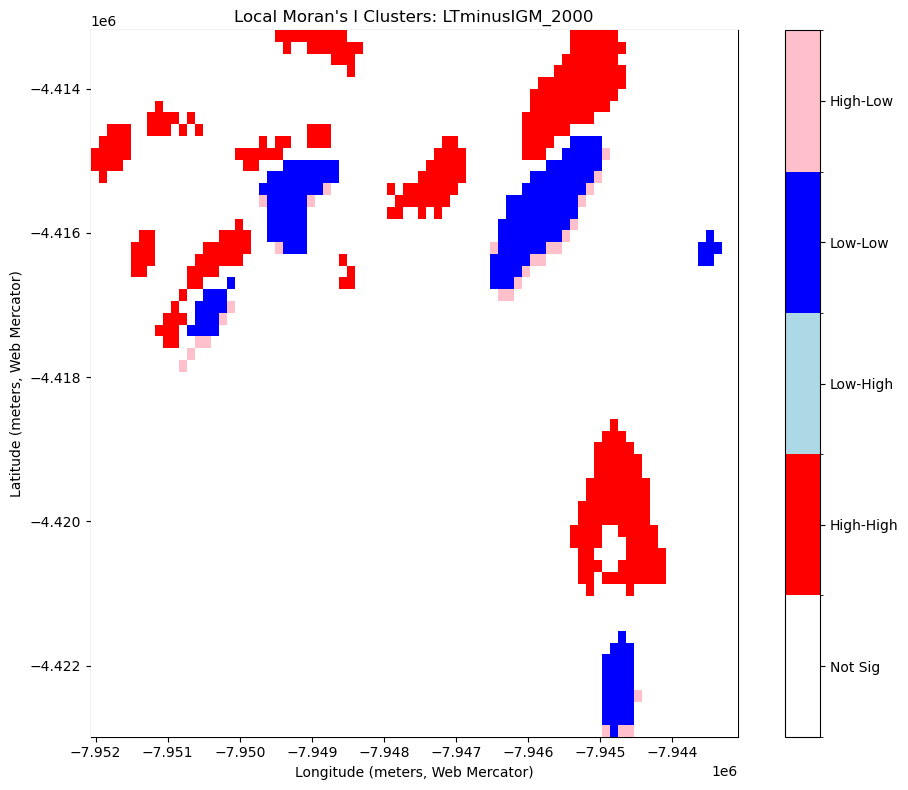


Analyzing SRTMminusIGM_2019
Data shape: 252 rows x 232 cols
Global Moran’s I: 0.6891, p-value: 0.0010


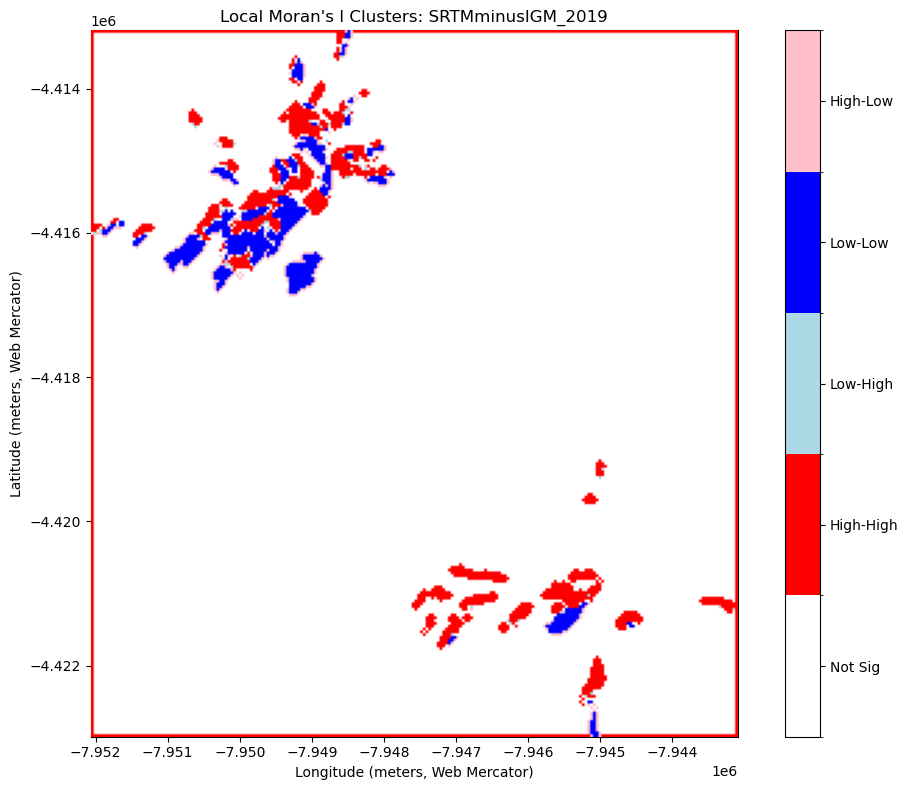


Analyzing CBminusSRTM_2019
Data shape: 37 rows x 46 cols
Global Moran’s I: 0.7894, p-value: 0.0010


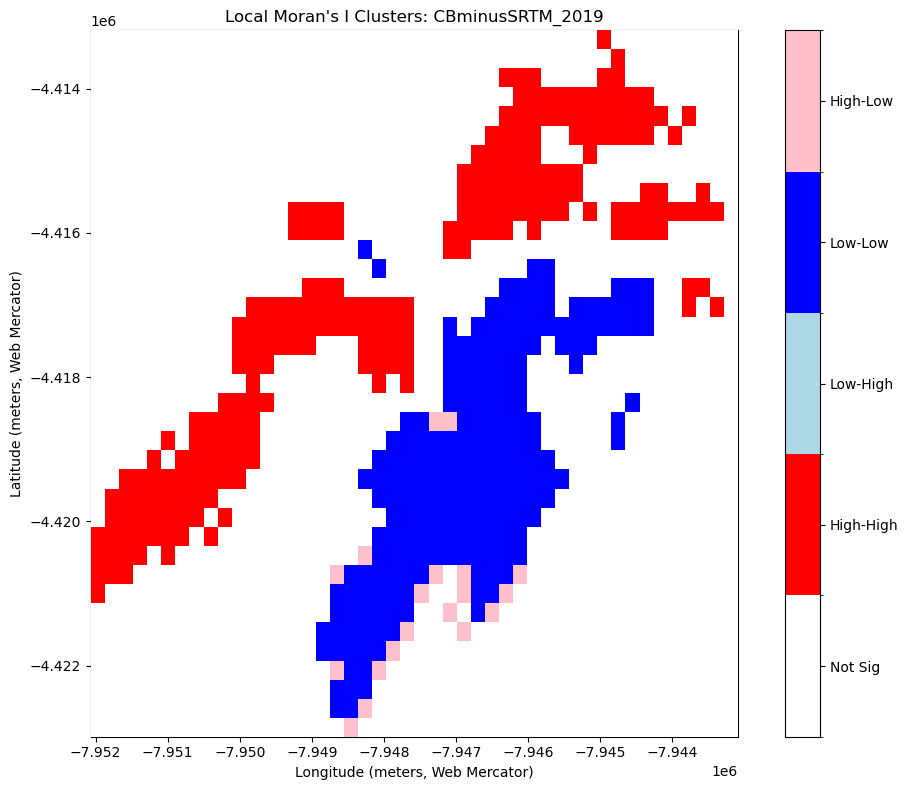


Analyzing LTminusSRTM_2019
Data shape: 61 rows x 81 cols
Global Moran’s I: 0.7707, p-value: 0.0010


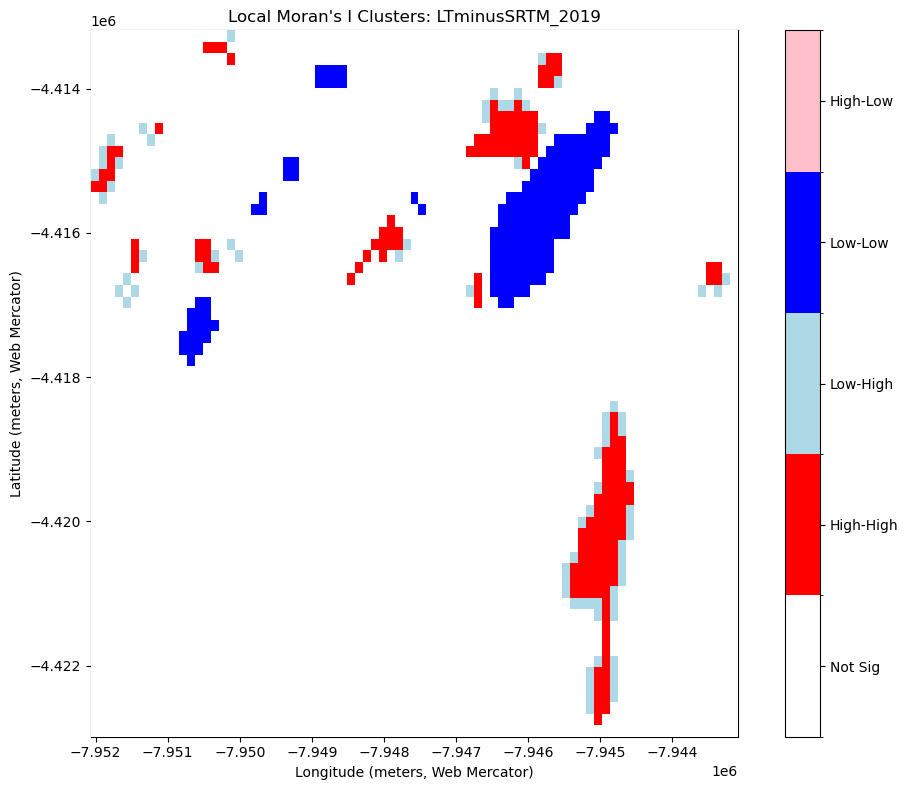


Analyzing CBminusIGM_2019
Data shape: 37 rows x 46 cols
Global Moran’s I: 0.7726, p-value: 0.0010


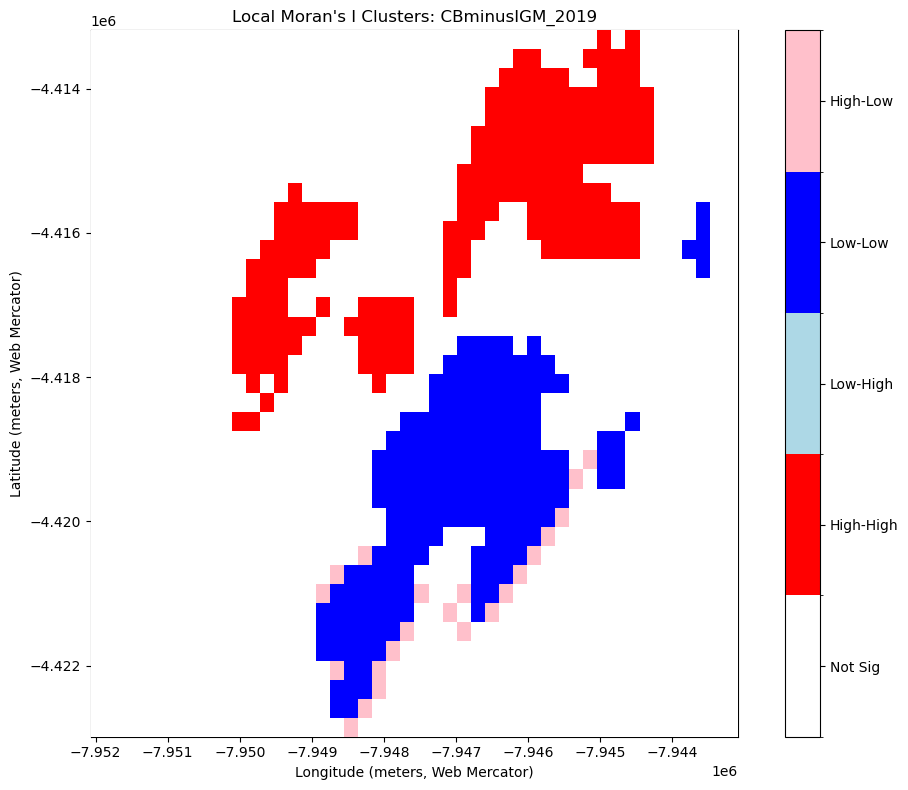


Analyzing LTminusIGM_2019
Data shape: 61 rows x 81 cols
Global Moran’s I: 0.7522, p-value: 0.0010


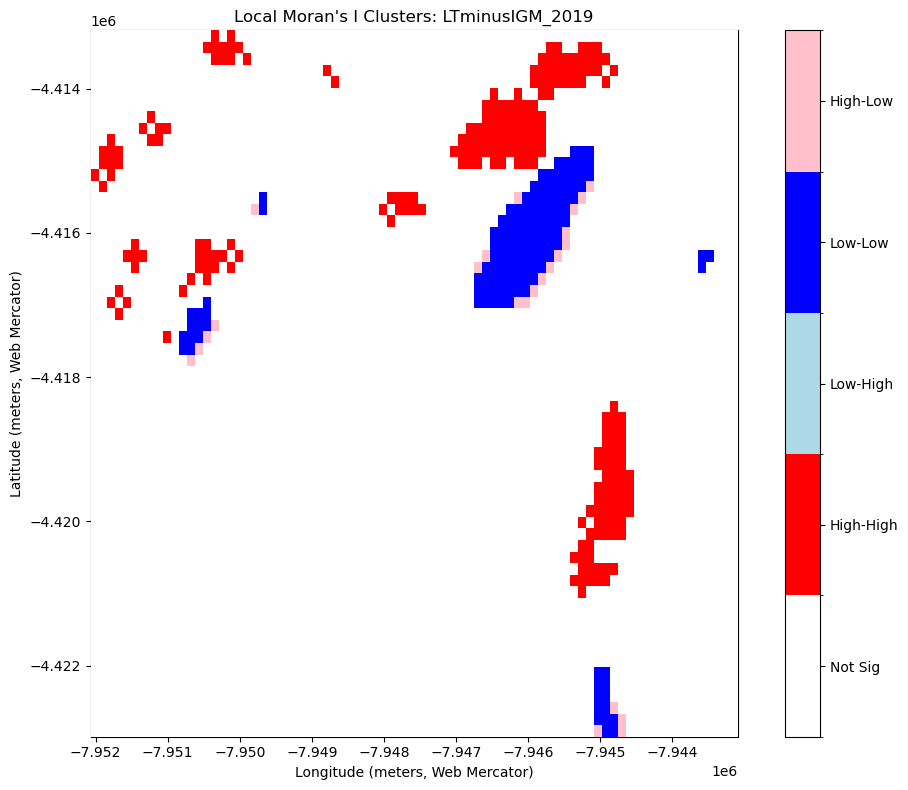

In [35]:
import os
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from esda.moran import Moran, Moran_Local
from libpysal.weights import lat2W
import matplotlib.colors as colors
import contextily as ctx
from rasterio.warp import transform_bounds
from rasterio.windows import Window
from rasterio.transform import xy

# ----------------------------
# Paths to elevation difference rasters
# ----------------------------
raster_paths = {
    "SRTMminusIGM_2000": "/Users/milliespencer/Desktop/dems_20250721_updated/output_data_baseIGM_poly2000_updated/SRTM_projected_raste_clp_diff.tif",
    "CBminusSRTM_2000": "/Users/milliespencer/Desktop/dems_20250721_updated/output_data_baseSRTM_poly2000/CerroBlanco_DEMproje_clp_diff.tif",
    "LTminusSRTM_2000": "/Users/milliespencer/Desktop/dems_20250721_updated/output_data_baseSRTM_poly2000/LasTermas_DEMproject_clp_diff.tif",
    "CBminusIGM_2000": "/Users/milliespencer/Desktop/dems_20250721_updated/output_data_baseIGM_poly2000_updated/CerroBlanco_DEMproje_clp_diff.tif",
    "LTminusIGM_2000": "/Users/milliespencer/Desktop/dems_20250721_updated/output_data_baseIGM_poly2000_updated/LasTermas_DEMproject_clp_diff.tif",
    "SRTMminusIGM_2019": "/Users/milliespencer/Desktop/dems_20250721_updated/output_data_baseIGM_poly2019_updated/SRTM_projected_raste_clp_diff.tif",
    "CBminusSRTM_2019": "/Users/milliespencer/Desktop/dems_20250721_updated/output_data_baseSRTM_poly2019/CerroBlanco_DEMproje_clp_diff.tif",
    "LTminusSRTM_2019": "/Users/milliespencer/Desktop/dems_20250721_updated/output_data_baseSRTM_poly2019/LasTermas_DEMproject_clp_diff.tif",
    "CBminusIGM_2019": "/Users/milliespencer/Desktop/dems_20250721_updated/output_data_baseIGM_poly2019_updated/CerroBlanco_DEMproje_clp_diff.tif",
    "LTminusIGM_2019": "/Users/milliespencer/Desktop/dems_20250721_updated/output_data_baseIGM_poly2019_updated/LasTermas_DEMproject_clp_diff.tif"
}

def load_clean_raster_subset(raster_path):
    with rasterio.open(raster_path) as src:
        data = src.read(1)
        data = np.where(data == src.nodata, np.nan, data)

        valid_mask = ~np.isnan(data)
        rows, cols = np.where(valid_mask)
        if len(rows) == 0:
            raise ValueError("No valid data in raster.")

        row_min, row_max = rows.min(), rows.max()
        col_min, col_max = cols.min(), cols.max()

        subset = data[row_min:row_max+1, col_min:col_max+1]

        # Replace any remaining NaNs with the mean value to avoid errors in Moran's I
        if np.isnan(subset).any():
            subset = np.where(np.isnan(subset), np.nanmean(subset), subset)

        # Convert to float64 to avoid numba dtype errors
        subset = subset.astype(np.float64)

        # Save window and transform info for plotting
        window = Window(col_off=col_min, row_off=row_min,
                        width=col_max - col_min + 1,
                        height=row_max - row_min + 1)
        transform = src.window_transform(window)
        crs = src.crs

        return subset, transform, crs

def analyze_morans_I(dh_array, transform, crs, raster_name):
    print(f"\nAnalyzing {raster_name}")
    print(f"Data shape: {dh_array.shape[0]} rows x {dh_array.shape[1]} cols")

    # Build spatial weights matrix (rook contiguity)
    w = lat2W(dh_array.shape[0], dh_array.shape[1])

    # Flatten raster values for Moran's I input
    z = dh_array.flatten()

    # Calculate Global Moran's I
    moran = Moran(z, w)

    print(f"Global Moran’s I: {moran.I:.4f}, p-value: {moran.p_sim:.4f}")

    # Local Moran's I
    local_moran = Moran_Local(z, w)

    # Prepare cluster map
    cluster_labels = local_moran.q  # 1 HH, 2 LH, 3 LL, 4 HL
    sig = local_moran.p_sim < 0.05

    # Create mask for significant clusters only
    sig_clusters = np.where(sig, cluster_labels, 0)
    sig_clusters = sig_clusters.reshape(dh_array.shape)

    # Define colors for cluster types
    cmap = colors.ListedColormap(['white', 'red', 'lightblue', 'blue', 'pink'])
    bounds = [0, 1, 2, 3, 4, 5]
    norm = colors.BoundaryNorm(bounds, cmap.N)

    # Transform extent to Web Mercator for contextily basemap ## what's happening here? Want in 3857 i think but not pos
    extent_4326 = transform_bounds(crs, 'EPSG:4326',
                                  transform[2], transform[5] + dh_array.shape[0]*transform[4],
                                  transform[2] + dh_array.shape[1]*transform[0], transform[5])
    extent_3857 = transform_bounds('EPSG:4326', 'EPSG:3857', *extent_4326)

    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(sig_clusters, cmap=cmap, norm=norm, extent=extent, origin='upper', zorder=10)

    cbar = plt.colorbar(im, ticks=[0.5, 1.5, 2.5, 3.5, 4.5], ax=ax)
    cbar.ax.set_yticklabels(['Not Sig', 'High-High', 'Low-High', 'Low-Low', 'High-Low'])
    ax.set_title(f"Local Moran's I Clusters: {raster_name}")
    ax.set_xlabel("Longitude (meters, Web Mercator)")
    ax.set_ylabel("Latitude (meters, Web Mercator)")

    # Add basemap from contextily
    ctx.add_basemap(ax, crs='EPSG:3857', source=ctx.providers.OpenStreetMap.Mapnik, zoom=9)

    plt.tight_layout()
    plt.show()

for raster_name, raster_path in raster_paths.items():
    try:
        dh_raster, transform, crs = load_clean_raster_subset(raster_path)
        analyze_morans_I(dh_raster, transform, crs, raster_name)
    except Exception as e:
        print(f"Error processing {raster_name}: {e}")


## Result: High degree of spatial autocorrelation. Most glaciers show either high-high (pixels with high elevation loss are near pixels with high elevation loss) and low-low (low elevation loss pixels have neighbors with low elevation loss). The Global Moran's I statistics are all >0.7, indicating that there is a strong positive spatial autocorrelation in our dataset. The p-values are below the threshold of 0.05, indicating that this spatial autocorrelation is statistically significant. This enables us to reject the null hypothesis that glacier thinning is randomly distributed across Nevados de Chillán's glaciers. The Local Moran's I plots show that the majority of pixels are surrounded by pixels with similar values (either high-high (red) or low-low (blue)). 
# Takeaway: glacier elevation loss is spatially coherent (not random). Low-low areas suggest relatively stable glacier zones, whereas high-high suggest regions of rapid glacier loss. 